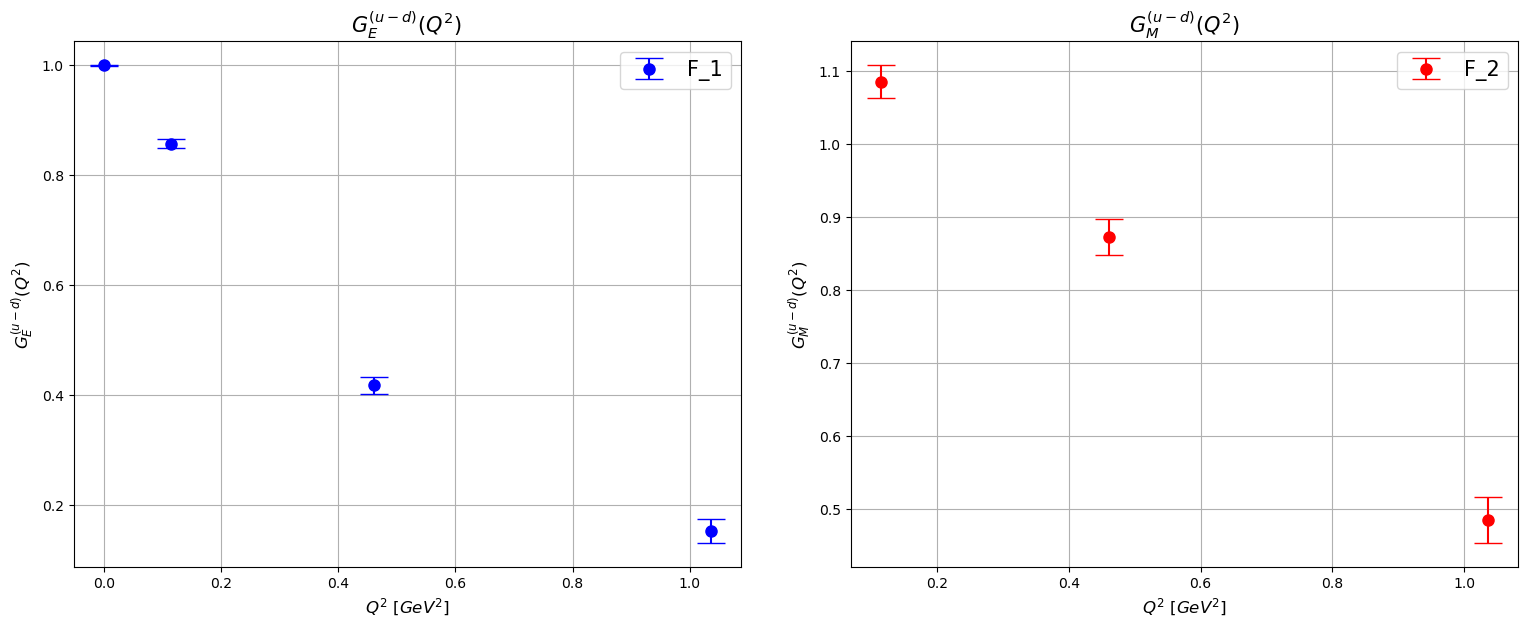

In [7]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from contextlib import ExitStack

#lattice size a
a = 0.114

# mass of the nucleon

MN = (1109*0.114)/(197)

# plateau_fit
def plateau_fit(x, y):
    return y*(x/x)

file_path = "/pscratch/sd/h/hari_8/saved_prop_files/save_3pt_2pt/save_3pt_2pt_cfgs_psnk_0_0_0__qy_cfg_1776_2092_.h5"

sources = [[0, 0, 0, 0], [8, 0, 0, 0], [16, 0, 0, 0], [24, 0, 0, 0], [0, 8, 0, 0], [0, 16, 0, 0], [0, 24, 0, 0], [0, 0, 8, 0], [0, 0, 16, 0], [0, 0, 24, 0]]
psnk = [0,0,0,0]
t = 10
tsnk = 10

def extract_3pt_2pt_cfg_list(tau, q, g):
    psrc = [(psnk[0] - q[0]), (psnk[1] - q[1]), (psnk[2] - q[2]), (psnk[3] - q[3])]
    with ExitStack() as stack:
        h5_file = stack.enter_context(h5py.File(file_path, "r"))
        no_cfgs = 0
        list_cfg_G3_U = []
        list_cfg_G3_D = []
        list_cfg_G2_t_psnk = []
        list_cfg_G2_tau_psnk = []
        list_cfg_G2_t_tau_psrc = []
        list_cfg_G2_tau_psrc = []
        list_cfg_G2_t_psrc = []
        list_cfg_G2_t_tau_psnk = []
        for cfg in range(1776, 2093, 4): #1984 #2092
            no_cfgs = no_cfgs + 1
            per_src_G3_U = []
            per_src_G3_D = []
            per_src_G2_t_psnk = []
            per_src_G2_tau_psnk = []
            per_src_G2_t_tau_psrc = []
            per_src_G2_tau_psrc = []
            per_src_G2_t_psrc = []
            per_src_G2_t_tau_psnk = []
            for csrc in sources:
                # 3pt U quark
                path_to_G3_U_vector = f"/cfg_{cfg}/ThreePT_flavor_U/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}/g{g}/qx{q[0]}_qy{q[1]}_qz{q[2]}"
                c_array_G3_U = h5_file[path_to_G3_U_vector]
                real_array_G3_U = (c_array_G3_U[()]).real
                per_src_G3_U.append(real_array_G3_U[tau])
                
                # 3pt D quark
                path_to_G3_D_vector = f"/cfg_{cfg}/ThreePT_flavor_D/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}/g{g}/qx{q[0]}_qy{q[1]}_qz{q[2]}"
                c_array_G3_D = h5_file[path_to_G3_D_vector]
                real_array_G3_D = (c_array_G3_D[()]).real
                per_src_G3_D.append(real_array_G3_D[tau])
                
                # 2pt G2(t,psnk)
                path_to_G2_t_psnk_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}"
                c_array_G2_t_psnk = h5_file[path_to_G2_t_psnk_c_vector]
                real_array_G2_t_psnk = (c_array_G2_t_psnk[()]).real
                per_src_G2_t_psnk.append(real_array_G2_t_psnk[t])
                
                # 2pt G2(tau,psnk)
                path_to_G2_tau_psnk_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}"
                c_array_G2_tau_psnk = h5_file[path_to_G2_tau_psnk_c_vector]
                real_array_G2_tau_psnk = (c_array_G2_tau_psnk[()]).real
                per_src_G2_tau_psnk.append(real_array_G2_tau_psnk[tau])
                
                # 2pt G2(t-tau,psrc)
                path_to_G2_t_tau_psrc_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psrc[0]}_PY{psrc[1]}_PZ{psrc[2]}_T{t}"
                c_array_G2_t_tau_psrc = h5_file[path_to_G2_t_tau_psrc_c_vector]
                real_array_G2_t_tau_psrc = (c_array_G2_t_tau_psrc[()]).real
                per_src_G2_t_tau_psrc.append(real_array_G2_t_tau_psrc[t-tau])
                
                # 2pt G2(tau,psrc)
                path_to_G2_tau_psrc_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psrc[0]}_PY{psrc[1]}_PZ{psrc[2]}_T{t}"
                c_array_G2_tau_psrc = h5_file[path_to_G2_tau_psrc_c_vector]
                real_array_G2_tau_psrc = (c_array_G2_tau_psrc[()]).real
                per_src_G2_tau_psrc.append(real_array_G2_tau_psrc[tau])
                
                # 2pt G2(t,psrc)
                path_to_G2_t_psrc_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psrc[0]}_PY{psrc[1]}_PZ{psrc[2]}_T{t}"
                c_array_G2_t_psrc = h5_file[path_to_G2_t_psrc_c_vector]
                real_array_G2_t_psrc = (c_array_G2_t_psrc[()]).real
                per_src_G2_t_psrc.append(real_array_G2_t_psrc[t])
                
                # 2pt G2(t-tau,psnk)
                path_to_G2_t_tau_psnk_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}"
                c_array_G2_t_tau_psnk = h5_file[path_to_G2_t_tau_psnk_c_vector]
                real_array_G2_t_tau_psnk = (c_array_G2_t_tau_psnk[()]).real
                per_src_G2_t_tau_psnk.append(real_array_G2_t_tau_psnk[t-tau])
                
            list_cfg_G3_U.append(np.mean(per_src_G3_U))
            list_cfg_G3_D.append(np.mean(per_src_G3_D))
            list_cfg_G2_t_psnk.append(np.mean(per_src_G2_t_psnk))
            list_cfg_G2_tau_psnk.append(np.mean(per_src_G2_tau_psnk))
            list_cfg_G2_t_tau_psrc.append(np.mean(per_src_G2_t_tau_psrc))
            list_cfg_G2_tau_psrc.append(np.mean(per_src_G2_tau_psrc))
            list_cfg_G2_t_psrc.append(np.mean(per_src_G2_t_psrc))
            list_cfg_G2_t_tau_psnk.append(np.mean(per_src_G2_t_tau_psnk))
    return list_cfg_G3_U, list_cfg_G3_D, list_cfg_G2_t_psnk, list_cfg_G2_tau_psnk, list_cfg_G2_t_tau_psrc, list_cfg_G2_tau_psrc, list_cfg_G2_t_psrc, list_cfg_G2_t_tau_psnk, no_cfgs

def jackknife_ratio_for_tau(tau, q, g):
    list_cfg_G3_U, list_cfg_G3_D, list_cfg_G2_t_psnk, list_cfg_G2_tau_psnk, list_cfg_G2_t_tau_psrc, list_cfg_G2_tau_psrc, list_cfg_G2_t_psrc, list_cfg_G2_t_tau_psnk, no_cfgs = extract_3pt_2pt_cfg_list(tau, q, g)
    G3_U = np.mean(list_cfg_G3_U)
    G3_D = np.mean(list_cfg_G3_D)
    G2_t_psnk = np.mean(list_cfg_G2_t_psnk)
    G2_tau_psnk = np.mean(list_cfg_G2_tau_psnk)
    G2_t_tau_psrc = np.mean(list_cfg_G2_t_tau_psrc)
    G2_tau_psrc = np.mean(list_cfg_G2_tau_psrc)
    G2_t_psrc = np.mean(list_cfg_G2_t_psrc)
    G2_t_tau_psnk = np.mean(list_cfg_G2_t_tau_psnk)
    Ratio = ((G3_U-G3_D)/G2_t_psnk)*np.sqrt((G2_tau_psnk*G2_t_psnk*G2_t_tau_psrc)/(G2_tau_psrc*G2_t_psrc*G2_t_tau_psnk))
    # making jackknife set
    sigma_square_Ratio = 0
    for i in range(len(list_cfg_G3_U)): #Jackknife
        sliced_list_cfg_G3_U = list_cfg_G3_U[:(i)] + list_cfg_G3_U[(i+1):]
        sliced_list_cfg_G3_D = list_cfg_G3_D[:(i)] + list_cfg_G3_D[(i+1):]
        sliced_list_cfg_G2_t_psnk = list_cfg_G2_t_psnk[:(i)] + list_cfg_G2_t_psnk[(i+1):]
        sliced_list_cfg_G2_tau_psnk = list_cfg_G2_tau_psnk[:(i)] + list_cfg_G2_tau_psnk[(i+1):]
        sliced_list_cfg_G2_t_tau_psrc = list_cfg_G2_t_tau_psrc[:(i)] + list_cfg_G2_t_tau_psrc[(i+1):]
        sliced_list_cfg_G2_tau_psrc = list_cfg_G2_tau_psrc[:(i)] + list_cfg_G2_tau_psrc[(i+1):]
        sliced_list_cfg_G2_t_psrc = list_cfg_G2_t_psrc[:(i)] + list_cfg_G2_t_psrc[(i+1):]
        sliced_list_cfg_G2_t_tau_psnk = list_cfg_G2_t_tau_psnk[:(i)] + list_cfg_G2_t_tau_psnk[(i+1):]
        #make averages of 2pts and 3pt for each jackknife set
        jackknife_G3_U = np.mean(sliced_list_cfg_G3_U)
        jackknife_G3_D = np.mean(sliced_list_cfg_G3_D)
        jackknife_G2_t_psnk = np.mean(sliced_list_cfg_G2_t_psnk)
        jackknife_G2_tau_psnk = np.mean(sliced_list_cfg_G2_tau_psnk)
        jackknife_G2_t_tau_psrc = np.mean(sliced_list_cfg_G2_t_tau_psrc)
        jackknife_G2_tau_psrc = np.mean(sliced_list_cfg_G2_tau_psrc)
        jackknife_G2_t_psrc = np.mean(sliced_list_cfg_G2_t_psrc)
        jackknife_G2_t_tau_psnk = np.mean(sliced_list_cfg_G2_t_tau_psnk)
        jackknife_Ratio = ((jackknife_G3_U-jackknife_G3_D)/jackknife_G2_t_psnk)*np.sqrt((jackknife_G2_tau_psnk*jackknife_G2_t_psnk*jackknife_G2_t_tau_psrc)/(jackknife_G2_tau_psrc*jackknife_G2_t_psrc*jackknife_G2_t_tau_psnk))
        sigma_square_Ratio = sigma_square_Ratio + np.square(Ratio-jackknife_Ratio)
    error_Ratio = np.sqrt(((no_cfgs-1)/(no_cfgs))*sigma_square_Ratio)
    return Ratio, error_Ratio, no_cfgs

def ratio_list_tau(q, g, plateau_t_i, plateau_t_f):
    ratio_list = []
    error_ratio_list = []
    for tau in (range(0, tsnk+1)):
        Ratio, error_Ratio, no_cfgs = jackknife_ratio_for_tau(tau, q, g) 
        ratio_list.append(Ratio)
        error_ratio_list.append(error_Ratio)
    ####################### Curve fitting #######################
    time_for_plateau = list(range(plateau_t_i, plateau_t_f + 1))
    ratio_3pt_list_plateau = []
    ratio_3pt_err_list_plateau = []
    for t_plateau in range(len(time_for_plateau)):
        ratio_3pt_list_plateau.append(ratio_list[t_plateau+plateau_t_i])
        ratio_3pt_err_list_plateau.append(error_ratio_list[t_plateau+plateau_t_i])
    params, cov = curve_fit(plateau_fit, time_for_plateau, ratio_3pt_list_plateau, sigma = ratio_3pt_err_list_plateau, absolute_sigma=True)
    ratio_3pt_2pt = params
    ratio_3pt_2pt_err = np.sqrt(np.diag(cov))
    #x_curve_plateau = np.linspace(np.min(time_for_plateau), np.max(time_for_plateau), 100)
    #y_curve_plateau = np.full(100, ratio_3pt_2pt) 
    return ratio_3pt_2pt, ratio_3pt_2pt_err


def extract_3pt_2pt_cfg_list_imag(tau, q, g):
    psrc = [(psnk[0] - q[0]), (psnk[1] - q[1]), (psnk[2] - q[2]), (psnk[3] - q[3])]
    with ExitStack() as stack:
        h5_file = stack.enter_context(h5py.File(file_path, "r"))
        no_cfgs = 0
        list_cfg_G3_U = []
        list_cfg_G3_D = []
        list_cfg_G2_t_psnk = []
        list_cfg_G2_tau_psnk = []
        list_cfg_G2_t_tau_psrc = []
        list_cfg_G2_tau_psrc = []
        list_cfg_G2_t_psrc = []
        list_cfg_G2_t_tau_psnk = []
        for cfg in range(1776, 2093, 4): #1984 #2092
            no_cfgs = no_cfgs + 1
            per_src_G3_U = []
            per_src_G3_D = []
            per_src_G2_t_psnk = []
            per_src_G2_tau_psnk = []
            per_src_G2_t_tau_psrc = []
            per_src_G2_tau_psrc = []
            per_src_G2_t_psrc = []
            per_src_G2_t_tau_psnk = []
            for csrc in sources:
                # 3pt U quark
                path_to_G3_U_vector = f"/cfg_{cfg}/ThreePT_flavor_U/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}/g{g}/qx{q[0]}_qy{q[1]}_qz{q[2]}"
                c_array_G3_U = h5_file[path_to_G3_U_vector]
                real_array_G3_U = (c_array_G3_U[()]).imag
                per_src_G3_U.append(real_array_G3_U[tau])
                
                # 3pt D quark
                path_to_G3_D_vector = f"/cfg_{cfg}/ThreePT_flavor_D/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}/g{g}/qx{q[0]}_qy{q[1]}_qz{q[2]}"
                c_array_G3_D = h5_file[path_to_G3_D_vector]
                real_array_G3_D = (c_array_G3_D[()]).imag
                per_src_G3_D.append(real_array_G3_D[tau])
                
                # 2pt G2(t,psnk)
                path_to_G2_t_psnk_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}"
                c_array_G2_t_psnk = h5_file[path_to_G2_t_psnk_c_vector]
                real_array_G2_t_psnk = (c_array_G2_t_psnk[()]).real
                per_src_G2_t_psnk.append(real_array_G2_t_psnk[t])
                
                # 2pt G2(tau,psnk)
                path_to_G2_tau_psnk_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}"
                c_array_G2_tau_psnk = h5_file[path_to_G2_tau_psnk_c_vector]
                real_array_G2_tau_psnk = (c_array_G2_tau_psnk[()]).real
                per_src_G2_tau_psnk.append(real_array_G2_tau_psnk[tau])
                
                # 2pt G2(t-tau,psrc)
                path_to_G2_t_tau_psrc_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psrc[0]}_PY{psrc[1]}_PZ{psrc[2]}_T{t}"
                c_array_G2_t_tau_psrc = h5_file[path_to_G2_t_tau_psrc_c_vector]
                real_array_G2_t_tau_psrc = (c_array_G2_t_tau_psrc[()]).real
                per_src_G2_t_tau_psrc.append(real_array_G2_t_tau_psrc[t-tau])
                
                # 2pt G2(tau,psrc)
                path_to_G2_tau_psrc_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psrc[0]}_PY{psrc[1]}_PZ{psrc[2]}_T{t}"
                c_array_G2_tau_psrc = h5_file[path_to_G2_tau_psrc_c_vector]
                real_array_G2_tau_psrc = (c_array_G2_tau_psrc[()]).real
                per_src_G2_tau_psrc.append(real_array_G2_tau_psrc[tau])
                
                # 2pt G2(t,psrc)
                path_to_G2_t_psrc_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psrc[0]}_PY{psrc[1]}_PZ{psrc[2]}_T{t}"
                c_array_G2_t_psrc = h5_file[path_to_G2_t_psrc_c_vector]
                real_array_G2_t_psrc = (c_array_G2_t_psrc[()]).real
                per_src_G2_t_psrc.append(real_array_G2_t_psrc[t])
                
                # 2pt G2(t-tau,psnk)
                path_to_G2_t_tau_psnk_c_vector = f"/cfg_{cfg}/TwoPT_proton3/x{csrc[0]}_y{csrc[1]}_z{csrc[2]}_t{csrc[3]}/PX{psnk[0]}_PY{psnk[1]}_PZ{psnk[2]}_T{t}"
                c_array_G2_t_tau_psnk = h5_file[path_to_G2_t_tau_psnk_c_vector]
                real_array_G2_t_tau_psnk = (c_array_G2_t_tau_psnk[()]).real
                per_src_G2_t_tau_psnk.append(real_array_G2_t_tau_psnk[t-tau])
                
            list_cfg_G3_U.append(np.mean(per_src_G3_U))
            list_cfg_G3_D.append(np.mean(per_src_G3_D))
            list_cfg_G2_t_psnk.append(np.mean(per_src_G2_t_psnk))
            list_cfg_G2_tau_psnk.append(np.mean(per_src_G2_tau_psnk))
            list_cfg_G2_t_tau_psrc.append(np.mean(per_src_G2_t_tau_psrc))
            list_cfg_G2_tau_psrc.append(np.mean(per_src_G2_tau_psrc))
            list_cfg_G2_t_psrc.append(np.mean(per_src_G2_t_psrc))
            list_cfg_G2_t_tau_psnk.append(np.mean(per_src_G2_t_tau_psnk))
    return list_cfg_G3_U, list_cfg_G3_D, list_cfg_G2_t_psnk, list_cfg_G2_tau_psnk, list_cfg_G2_t_tau_psrc, list_cfg_G2_tau_psrc, list_cfg_G2_t_psrc, list_cfg_G2_t_tau_psnk, no_cfgs

def jackknife_ratio_for_tau_imag(tau, q, g):
    list_cfg_G3_U, list_cfg_G3_D, list_cfg_G2_t_psnk, list_cfg_G2_tau_psnk, list_cfg_G2_t_tau_psrc, list_cfg_G2_tau_psrc, list_cfg_G2_t_psrc, list_cfg_G2_t_tau_psnk, no_cfgs = extract_3pt_2pt_cfg_list_imag(tau, q, g)
    G3_U = np.mean(list_cfg_G3_U)
    G3_D = np.mean(list_cfg_G3_D)
    G2_t_psnk = np.mean(list_cfg_G2_t_psnk)
    G2_tau_psnk = np.mean(list_cfg_G2_tau_psnk)
    G2_t_tau_psrc = np.mean(list_cfg_G2_t_tau_psrc)
    G2_tau_psrc = np.mean(list_cfg_G2_tau_psrc)
    G2_t_psrc = np.mean(list_cfg_G2_t_psrc)
    G2_t_tau_psnk = np.mean(list_cfg_G2_t_tau_psnk)
    Ratio = ((G3_U-G3_D)/G2_t_psnk)*np.sqrt((G2_tau_psnk*G2_t_psnk*G2_t_tau_psrc)/(G2_tau_psrc*G2_t_psrc*G2_t_tau_psnk))
    # making jackknife set
    sigma_square_Ratio = 0
    for i in range(len(list_cfg_G3_U)): #Jackknife
        sliced_list_cfg_G3_U = list_cfg_G3_U[:(i)] + list_cfg_G3_U[(i+1):]
        sliced_list_cfg_G3_D = list_cfg_G3_D[:(i)] + list_cfg_G3_D[(i+1):]
        sliced_list_cfg_G2_t_psnk = list_cfg_G2_t_psnk[:(i)] + list_cfg_G2_t_psnk[(i+1):]
        sliced_list_cfg_G2_tau_psnk = list_cfg_G2_tau_psnk[:(i)] + list_cfg_G2_tau_psnk[(i+1):]
        sliced_list_cfg_G2_t_tau_psrc = list_cfg_G2_t_tau_psrc[:(i)] + list_cfg_G2_t_tau_psrc[(i+1):]
        sliced_list_cfg_G2_tau_psrc = list_cfg_G2_tau_psrc[:(i)] + list_cfg_G2_tau_psrc[(i+1):]
        sliced_list_cfg_G2_t_psrc = list_cfg_G2_t_psrc[:(i)] + list_cfg_G2_t_psrc[(i+1):]
        sliced_list_cfg_G2_t_tau_psnk = list_cfg_G2_t_tau_psnk[:(i)] + list_cfg_G2_t_tau_psnk[(i+1):]
        #make averages of 2pts and 3pt for each jackknife set
        jackknife_G3_U = np.mean(sliced_list_cfg_G3_U)
        jackknife_G3_D = np.mean(sliced_list_cfg_G3_D)
        jackknife_G2_t_psnk = np.mean(sliced_list_cfg_G2_t_psnk)
        jackknife_G2_tau_psnk = np.mean(sliced_list_cfg_G2_tau_psnk)
        jackknife_G2_t_tau_psrc = np.mean(sliced_list_cfg_G2_t_tau_psrc)
        jackknife_G2_tau_psrc = np.mean(sliced_list_cfg_G2_tau_psrc)
        jackknife_G2_t_psrc = np.mean(sliced_list_cfg_G2_t_psrc)
        jackknife_G2_t_tau_psnk = np.mean(sliced_list_cfg_G2_t_tau_psnk)
        jackknife_Ratio = ((jackknife_G3_U-jackknife_G3_D)/jackknife_G2_t_psnk)*np.sqrt((jackknife_G2_tau_psnk*jackknife_G2_t_psnk*jackknife_G2_t_tau_psrc)/(jackknife_G2_tau_psrc*jackknife_G2_t_psrc*jackknife_G2_t_tau_psnk))
        sigma_square_Ratio = sigma_square_Ratio + np.square(Ratio-jackknife_Ratio)
    error_Ratio = np.sqrt(((no_cfgs-1)/(no_cfgs))*sigma_square_Ratio)
    return Ratio, error_Ratio, no_cfgs

def ratio_list_tau_imag(q, g, plateau_t_i, plateau_t_f):
    ratio_list = []
    error_ratio_list = []
    for tau in (range(0, tsnk+1)):
        Ratio, error_Ratio, no_cfgs = jackknife_ratio_for_tau_imag(tau, q, g) 
        ratio_list.append(Ratio)
        error_ratio_list.append(error_Ratio)
    ####################### Curve fitting #######################
    time_for_plateau = list(range(plateau_t_i, plateau_t_f + 1))
    ratio_3pt_list_plateau = []
    ratio_3pt_err_list_plateau = []
    for t_plateau in range(len(time_for_plateau)):
        ratio_3pt_list_plateau.append(ratio_list[t_plateau+plateau_t_i])
        ratio_3pt_err_list_plateau.append(error_ratio_list[t_plateau+plateau_t_i])
    params, cov = curve_fit(plateau_fit, time_for_plateau, ratio_3pt_list_plateau, sigma = ratio_3pt_err_list_plateau, absolute_sigma=True)
    ratio_3pt_2pt = params
    ratio_3pt_2pt_err = np.sqrt(np.diag(cov))
    #x_curve_plateau = np.linspace(np.min(time_for_plateau), np.max(time_for_plateau), 100)
    #y_curve_plateau = np.full(100, ratio_3pt_2pt) 
    return ratio_3pt_2pt, ratio_3pt_2pt_err



def form_factor_G_from_Lin_Meyer(q_list):
    list_q_square = []
    K_list = []
    qEM_list = []
    for i, q in enumerate(q_list): 
        q_three = np.square((q[0]*2*np.pi*197)/(a*32))+np.square((q[1]*2*np.pi*197)/(a*32))+np.square((q[2]*2*np.pi*197)/(a*32))
        list_q_square.append(q_three/1000000)
        psrc = [(psnk[0] - q[0]), (psnk[1] - q[1]), (psnk[2] - q[2]), (psnk[3] - q[3])]
        EP = np.sqrt(np.square(psrc[0])+np.square(psrc[1])+np.square(psrc[2])+np.square(MN))
        K = np.sqrt((EP+MN)/(2*EP))
        K_list.append(K)
        qEM = (-q[1])/(EP+MN)
        qEM_list.append(qEM)
    R4qx_0, R4qx_0_err = ratio_list_tau(q_list[0], 8, 3, 8)
    R4qx_1, R4qx_1_err = ratio_list_tau(q_list[1], 8, 3, 8)
    R4qx_2, R4qx_2_err = ratio_list_tau(q_list[2], 8, 3, 8)
    R4qx_3, R4qx_3_err = ratio_list_tau(q_list[3], 8, 3, 8)
    list_G_E = [((R4qx_0[0])/(K_list[0])), ((R4qx_1[0])/(K_list[1])), ((R4qx_2[0])/(K_list[2])), ((R4qx_3[0])/(K_list[3]))]
    list_G_E_err = [((R4qx_0_err[0])/(K_list[0])), ((R4qx_1_err[0])/(K_list[1])), ((R4qx_2_err[0])/(K_list[2])), ((R4qx_3_err[0])/(K_list[3]))]
    normalized_list_G_E = []
    normalized_list_G_E_err = []
    for j in range(0,4):
        normalized_list_G_E.append(list_G_E[j]/list_G_E[0])
    for k in range(0,4):
        normalized_list_G_E_err.append(abs(normalized_list_G_E[k]*np.sqrt(np.square(list_G_E_err[k]/list_G_E[k])+np.square(list_G_E_err[0]/list_G_E[0]))))
        
    #  G_M
    R2qx_1, R2qx_1_err = ratio_list_tau(q_list[1], 1, 3, 8)
    R2qx_2, R2qx_2_err = ratio_list_tau(q_list[2], 1, 3, 8)
    R2qx_3, R2qx_3_err = ratio_list_tau(q_list[3], 1, 3, 8)
    list_G_M = [ ((R2qx_1[0])/(K_list[1]*qEM_list[1])), ((R2qx_2[0])/(K_list[2]*qEM_list[2])), ((R2qx_3[0])/(K_list[3]*qEM_list[3]))]
    list_G_M_err = [abs((R2qx_1_err[0])/(K_list[1]*qEM_list[1])), abs((R2qx_2_err[0])/(K_list[2]*qEM_list[2])), abs((R2qx_3_err[0])/(K_list[3]*qEM_list[3]))]
    normalized_list_G_M = []
    normalized_list_G_M_err = []
    for j in range(0,3):
        normalized_list_G_M.append(list_G_M[j]/list_G_E[0])
    for k in range(0,3):
        normalized_list_G_M_err.append(abs(normalized_list_G_M[k]*np.sqrt(np.square(list_G_M_err[k]/list_G_M[k])+np.square(list_G_E_err[0]/list_G_E[0]))))
   
    fig = plt.figure(figsize=(16, 7))
    plt.subplot(1, 2, 1)
    plt.errorbar(list_q_square, normalized_list_G_E, yerr = normalized_list_G_E_err, fmt='o', markersize=8, capsize=10, color='blue', label= "F_1")
    #plt.plot(x_curve, y_curve, 'r--', label='$\\frac{F_{1}(Q^2)}{F_{1}(0)}=1+\\frac{1}{6}\\frac{18}{M_{T}^{2}}Q^{2}$')
    plt.ylabel("$G_{E}^{(u-d)}(Q^2)$", fontsize=12)
    plt.xlabel("$Q^{2}~[GeV^2]$", fontsize=12)
    plt.tight_layout(pad=3.3)
    #plt.title("$F_{1}^{(u-d)}(Q^2)$            $M_T=(%.4f \u00B1 %.4f)$ GeV$^2$"%(MD_fit, MD_err), fontsize=15)
    plt.title("$G_{E}^{(u-d)}(Q^2)$ ", fontsize=15)
    plt.legend(fontsize=15)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True) 
    
    plt.subplot(1, 2, 2)
    plt.errorbar(list_q_square[1:], normalized_list_G_M, yerr = normalized_list_G_M_err, fmt='o', markersize=8, capsize=10, color='red', label= "F_2")
    plt.ylabel("$G_{M}^{(u-d)}(Q^2)$", fontsize=12)
    plt.xlabel("$Q^{2}~[GeV^2]$", fontsize=12)
    plt.tight_layout(pad=3.3)
    plt.title("$G_{M}^{(u-d)}(Q^2)$", fontsize=15)
    plt.legend(fontsize=15)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True) 
    plt.show()
    return

q_list_2 = [[0,0,0,0], [0,1,0,0], [0,2,0,0], [0,3,0,0]]
form_factor_G(q_list_2)

